<div style="margin-bottom: 32px;">
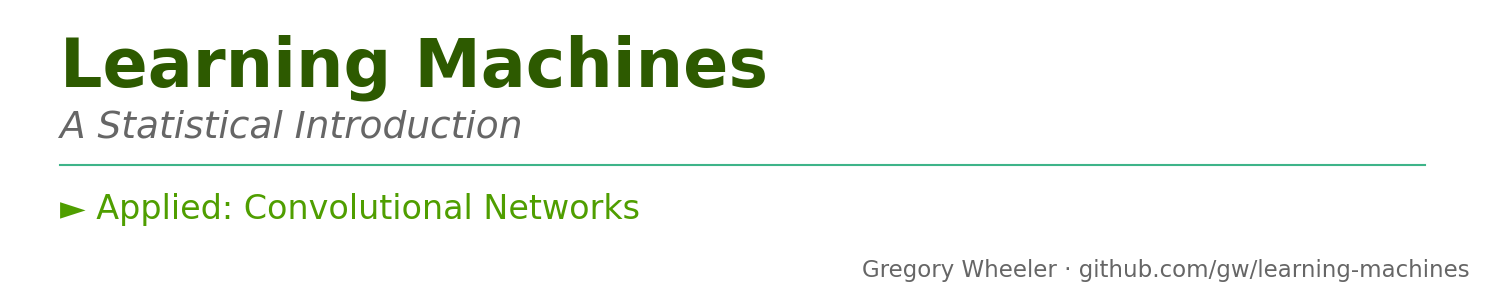
</div>


# Applied — A Convolutional Network

Rung two. The dataset is the same Fashion-MNIST as Chapter 9, and the **training loop is identical**—only the model changes, from a flat MLP that ignores the layout of the pixels to a *convolutional* network that exploits it. You will build a **residual block**: the skip connection of Chapter 10's ResNets and—not by coincidence—the same `x + F(x)` that lets the transformer block of the GPT capstone train when it is deep.

One cell is marked **🔧 Your turn**: the residual connection. A reference follows.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import mlone_theme as mt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

plt.style.use("mlone_style.mplstyle")
mt.set_notebook_mode()
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


## The data, as images

The same subsample of Fashion-MNIST as Chapter 9, but kept as $1\times28\times28$ images rather than flattened—a convolution needs the grid.

In [2]:
classes = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

X, y = fetch_openml("Fashion-MNIST", version=1, as_frame=False, return_X_y=True)
X = (X / 255.0).astype("float32")
y = y.astype(int)

subset = np.random.permutation(len(X))[:15000]
X, y = X[subset], y[subset]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

to_images = lambda A: torch.tensor(A).reshape(-1, 1, 28, 28)   # (N, channels, H, W)
X_tr, X_te = to_images(X_tr), to_images(X_te)
y_tr, y_te = torch.tensor(y_tr), torch.tensor(y_te)
print(f"{len(X_tr)} train, {len(X_te)} test images of shape {tuple(X_tr.shape[1:])}")

12000 train, 3000 test images of shape (1, 28, 28)


## A residual block

Stacking many convolutions makes optimization hard (Chapter 10); a **residual block** fixes it by adding the block's input back to its output, so each block only has to learn a *correction* to the identity. That added "+ x" is the gradient highway of Exercise 9.9—and it is exactly the construction wrapped around attention and the feed-forward network inside a transformer block.

**🔧 Your turn.** Implement `ResidualBlock.forward`: two padded convolutions (each with batch normalization and ReLU), then add the input back before the final activation. A reference follows.

In [3]:
class ResidualBlock(nn.Module):
    """Two same-shape convolutions with a skip connection: relu(x + F(x))."""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(channels)
        self.relu  = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + x)            # the residual connection

## The model

A small convolutional network: two convolution-and-pool stages that shrink $28\times28$ to $7\times7$ while growing the channels, one residual block, and a linear head to ten classes. Notice the parameter count—far smaller than Chapter 9's MLP (about 235k), because a convolution shares one small filter across the whole image.

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 28 -> 14
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 14 -> 7
            ResidualBlock(32),
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(32 * 7 * 7, 10))

    def forward(self, x):
        return self.head(self.features(x))

model = CNN().to(device)
print(f"{sum(p.numel() for p in model.parameters()) / 1e3:.0f}k parameters  (the MLP had 235k)")

39k parameters  (the MLP had 235k)


## Training — the same loop

The loop below is the one from Chapter 9, unchanged. That is the point: swapping the model does not change how we train it. (Accuracy is evaluated in batches because the convolutions hold more activations in memory than the MLP did.)

In [5]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
batch_size, epochs = 128, 10

@torch.no_grad()
def accuracy(X, Y):
    model.eval()
    correct = torch.cat([(model(X[i : i + 512]).argmax(1) == Y[i : i + 512])
                         for i in range(0, len(X), 512)])
    model.train()
    return correct.float().mean().item()

history = []
for epoch in range(epochs):
    order = torch.randperm(len(X_tr))
    for i in range(0, len(X_tr), batch_size):
        batch = order[i : i + batch_size]
        loss = loss_fn(model(X_tr[batch]), y_tr[batch])
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
    history.append((epoch, loss.item(), accuracy(X_te, y_te)))
    print(f"epoch {epoch + 1:2d} | train loss {loss.item():.3f} | test accuracy {history[-1][2]:.3f}")

epoch  1 | train loss 0.585 | test accuracy 0.835


epoch  2 | train loss 0.309 | test accuracy 0.849


epoch  3 | train loss 0.386 | test accuracy 0.873


epoch  4 | train loss 0.392 | test accuracy 0.863


epoch  5 | train loss 0.169 | test accuracy 0.886


epoch  6 | train loss 0.416 | test accuracy 0.874


epoch  7 | train loss 0.345 | test accuracy 0.876


epoch  8 | train loss 0.214 | test accuracy 0.884


epoch  9 | train loss 0.124 | test accuracy 0.885


epoch 10 | train loss 0.075 | test accuracy 0.882


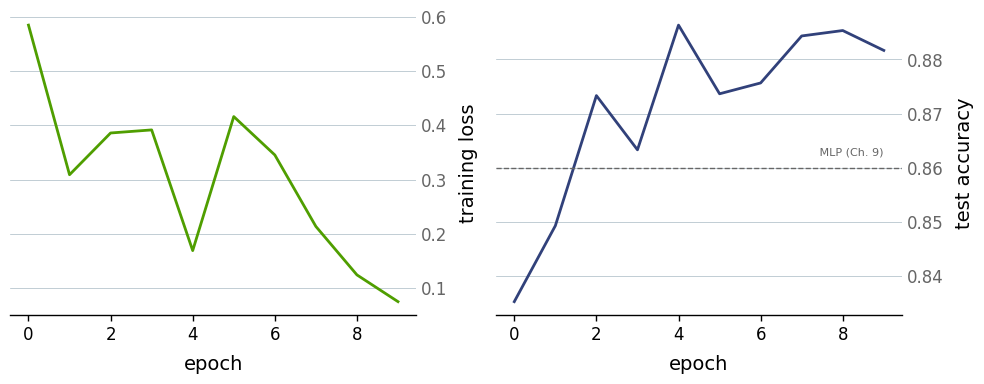

final test accuracy: 0.882


In [6]:
ep, tr_loss, te_acc = zip(*history)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4))
a1.plot(ep, tr_loss, color=mt.GREEN,   lw=2); a1.set_xlabel("epoch"); a1.set_ylabel("training loss")
a2.plot(ep, te_acc,  color=mt.FS_BLUE, lw=2); a2.set_xlabel("epoch"); a2.set_ylabel("test accuracy")
a2.axhline(0.86, color=mt.GRAY, ls="--", lw=1)              # the Chapter 9 MLP, for comparison
a2.text(ep[-1], 0.862, " MLP (Ch. 9)", color=mt.GRAY, fontsize=8, ha="right", va="bottom")
mt.apply_economist_style(a1); mt.apply_economist_style(a2)
fig.tight_layout()
plt.show()
print(f"final test accuracy: {te_acc[-1]:.3f}")

## Fewer parameters, better accuracy

The convolutional network beats the Chapter 9 MLP with a fraction of the parameters. Its **inductive bias**—locality and translation equivariance—matches images, so it spends parameters where they help; the residual block let us add depth without making optimization harder.

**Where this is heading.** The residual you wrote is the same `x + F(x)` that wraps attention and the feed-forward network in a transformer block. In Chapter 11 you build the attention that goes *inside* that block; in Chapter 12 you assemble the whole thing into a GPT—still trained by the loop you have now used twice.

## Try next

- Remove the residual block (send the second pooling output straight to the head) and instead stack two more plain convolutions; does training get harder or the accuracy worse?
- Add a second residual block, or widen the channels from 32; how high can you push the test accuracy before it stops helping?